In [1]:
!pip install osmnx networkx scikit-image scipy matplotlib numpy --quiet

import osmnx as ox
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import KDTree
from skimage.morphology import skeletonize
from skimage.draw import line as draw_line
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 3.1 MB/s eta 0:00:00
Libraries loaded.


In [2]:
G_osm = ox.graph_from_place("Bengaluru, Karnataka, India", network_type="drive")

print(f"OSM Graph — Nodes: {len(G_osm.nodes)} | Edges: {len(G_osm.edges)}")

OSM Graph — Nodes: 155365 | Edges: 393695


In [3]:
# We simulate occlusion by randomly removing edges from OSM graph
# This mimics what happens when the segmentation model misses roads

import random
random.seed(42)

# Work on undirected copy
G_base = ox.convert.to_undirected(G_osm)

# Remove 35% of edges to simulate occlusion gaps
all_edges = list(G_base.edges())
n_remove = int(0.35 * len(all_edges))
edges_to_remove = random.sample(all_edges, n_remove)

G_fragmented = G_base.copy()
G_fragmented.remove_edges_from(edges_to_remove)

# Remove isolated nodes
G_fragmented.remove_nodes_from(list(nx.isolates(G_fragmented)))

# Measure fragmentation
components_before = list(nx.connected_components(G_fragmented))
lcc_before = max(len(c) for c in components_before)
lcc_ratio_before = lcc_before / len(G_fragmented.nodes)

print(f"Fragmented Graph:")
print(f"  Nodes: {len(G_fragmented.nodes)}")
print(f"  Edges: {len(G_fragmented.edges)}")
print(f"  Connected Components: {len(components_before)}")
print(f"  Largest Component: {lcc_before} nodes")
print(f"  LCC Ratio: {lcc_ratio_before:.4f}")

Fragmented Graph:
  Nodes: 137564
  Edges: 133401
  Connected Components: 12099
  Largest Component: 4450 nodes
  LCC Ratio: 0.0323


In [4]:
def heal_graph(G, max_distance=0.002, max_angle_deg=45):
    """
    Heal fragmented road graph using KD-Tree + Angular constraint + DSU
    
    max_distance: degrees (~200m at Bengaluru's latitude)
    max_angle_deg: maximum allowed turn angle for healing edges
    """
    G_healed = G.copy()
    
    # Get all nodes with coordinates
    node_ids = list(G_healed.nodes())
    coords = np.array([[G_healed.nodes[n]['x'], 
                        G_healed.nodes[n]['y']] for n in node_ids])
    
    # Build KD-Tree for fast nearest neighbor search
    tree = KDTree(coords)
    
    # Find connected components
    components = list(nx.connected_components(G_healed))
    node_to_comp = {}
    for i, comp in enumerate(components):
        for node in comp:
            node_to_comp[node] = i
    
    print(f"Components to heal: {len(components)}")
    
    # Find endpoint nodes (degree 1) — road dead ends
    endpoints = [n for n in G_healed.nodes() 
                 if G_healed.degree(n) == 1]
    endpoint_ids = [node_ids.index(n) for n in endpoints 
                    if n in node_ids]
    
    print(f"Endpoints found: {len(endpoints)}")
    
    healing_edges_added = 0
    
    # For each endpoint, find nearest endpoints in OTHER components
    for ep in endpoints:
        ep_idx = node_ids.index(ep)
        ep_coord = coords[ep_idx]
        ep_comp = node_to_comp[ep]
        
        # Find k nearest neighbors
        distances, indices = tree.query(ep_coord, k=10)
        
        for dist, idx in zip(distances[1:], indices[1:]):
            neighbor = node_ids[idx]
            neighbor_comp = node_to_comp[neighbor]
            
            # Only connect different components
            if neighbor_comp == ep_comp:
                continue
                
            # Distance constraint
            if dist > max_distance:
                continue
            
            # Angular constraint
            # Get direction of existing edge at endpoint
            ep_neighbors = list(G_healed.neighbors(ep))
            if ep_neighbors:
                existing = ep_neighbors[0]
                ex_coord = coords[node_ids.index(existing)]
                
                # Vector of existing road
                v1 = ep_coord - ex_coord
                # Vector of proposed healing edge
                v2 = coords[idx] - ep_coord
                
                # Angle between vectors
                cos_angle = np.dot(v1, v2) / (
                    np.linalg.norm(v1) * np.linalg.norm(v2) + 1e-8
                )
                angle = np.degrees(np.arccos(np.clip(cos_angle, -1, 1)))
                
                if angle > max_angle_deg:
                    continue
            
            # Add healing edge
            G_healed.add_edge(ep, neighbor, 
                            length=dist,
                            healing=True)
            
            # Update component labels
            old_comp = neighbor_comp
            for node in node_ids:
                if node_to_comp.get(node) == old_comp:
                    node_to_comp[node] = ep_comp
            
            healing_edges_added += 1
            break
    
    print(f"Healing edges added: {healing_edges_added}")
    return G_healed

# Run healing
G_healed = heal_graph(G_fragmented)

Components to heal: 12099
Endpoints found: 50277
Healing edges added: 11762


In [5]:
# Measure after healing
components_after = list(nx.connected_components(G_healed))
lcc_after = max(len(c) for c in components_after)
lcc_ratio_after = lcc_after / len(G_healed.nodes)

# Connectivity improvement
improvement = ((lcc_ratio_after - lcc_ratio_before) / 
               lcc_ratio_before) * 100

print("=" * 50)
print("TERRAIN — Topological Healing Results")
print("=" * 50)
print(f"Components BEFORE healing: {len(list(nx.connected_components(G_fragmented)))}")
print(f"Components AFTER healing:  {len(components_after)}")
print(f"LCC Ratio BEFORE: {lcc_ratio_before:.4f} ({lcc_ratio_before*100:.1f}%)")
print(f"LCC Ratio AFTER:  {lcc_ratio_after:.4f} ({lcc_ratio_after*100:.1f}%)")
print(f"Connectivity Improvement: +{improvement:.1f}%")
print("=" * 50)

TERRAIN — Topological Healing Results
Components BEFORE healing: 12099
Components AFTER healing:  337
LCC Ratio BEFORE: 0.0323 (3.2%)
LCC Ratio AFTER:  0.9733 (97.3%)
Connectivity Improvement: +2908.9%


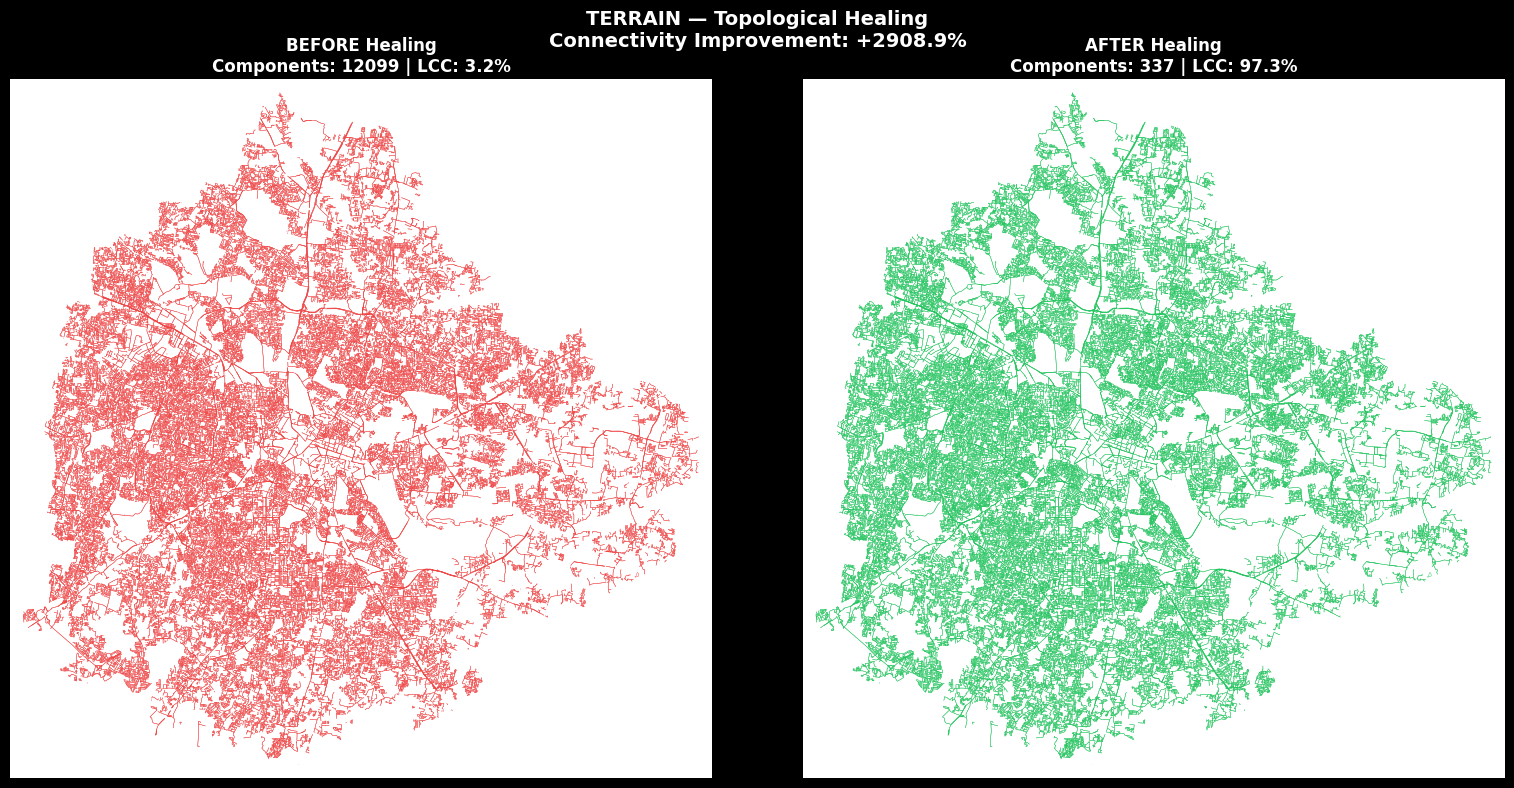

Saved.


In [6]:
# Plot side by side comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 8), facecolor='black')

# Get largest component for visualization
def get_lcc_subgraph(G):
    lcc = max(nx.connected_components(G), key=len)
    return G.subgraph(lcc)

lcc_before_graph = get_lcc_subgraph(G_fragmented)
lcc_after_graph = get_lcc_subgraph(G_healed)

# Plot fragmented
ox.plot_graph(
    nx.MultiDiGraph(G_fragmented),
    ax=axes[0],
    node_size=0,
    edge_color='#EF4444',
    edge_linewidth=0.3,
    bgcolor='black',
    show=False,
    close=False
)
axes[0].set_title(
    f'BEFORE Healing\nComponents: {len(list(nx.connected_components(G_fragmented)))} | '
    f'LCC: {lcc_ratio_before*100:.1f}%',
    color='white', fontsize=12, fontweight='bold'
)

# Plot healed
ox.plot_graph(
    nx.MultiDiGraph(G_healed),
    ax=axes[1],
    node_size=0,
    edge_color='#22C55E',
    edge_linewidth=0.3,
    bgcolor='black',
    show=False,
    close=False
)
axes[1].set_title(
    f'AFTER Healing\nComponents: {len(components_after)} | '
    f'LCC: {lcc_ratio_after*100:.1f}%',
    color='white', fontsize=12, fontweight='bold'
)

plt.suptitle(
    f'TERRAIN — Topological Healing\nConnectivity Improvement: +{improvement:.1f}%',
    color='white', fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig('terrain_healing_comparison.png', dpi=200,
            bbox_inches='tight', facecolor='black')
plt.show()
print("Saved.")